In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Walmart DataSet.csv')

In [ ]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.dtypes

,0
Store,int64
Date,object
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [ ]:
print(df.shape)

(6435, 8)


In [ ]:
# Changing the datatype of the 'Date' column because it is an object type
from datetime import datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df.dtypes

,0
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


In [ ]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
# Statistical Tasks--

In [ ]:
# Which store has maximum sales?
total_sales=df.groupby('Store')['Weekly_Sales'].sum().round().sort_values(ascending=False)
total_sales

,Weekly_Sales
Store,
20,301397792.0
4,299543953.0
14,288999911.0
13,286517704.0
2,275382441.0
10,271617714.0
27,253855917.0
6,223756131.0
1,222402809.0


In [ ]:
pd.DataFrame(total_sales).head(1)

,Weekly_Sales
Store,
20,301397792.0


In [ ]:
# Which store has maximum standard deviation i.e., the sales vary a lot
# Also, find out the coefficient of mean to standard deviation

In [ ]:
  df_std=df.groupby('Store')['Weekly_Sales'].std().round().sort_values(ascending=False)

In [ ]:
pd.DataFrame(df_std).head()

,Weekly_Sales
Store,
14,317570.0
10,302262.0
20,275901.0
4,266201.0
13,265507.0


In [ ]:
# Store which has the maximum standard deviation
pd.DataFrame(df_std).head(1)

,Weekly_Sales
Store,
14,317570.0


In [ ]:
# Coefficient of mean to standard deviation

In [ ]:
store14=df[df.Store==14].Weekly_Sales

In [ ]:
mean_to_stddev=store14.std()/store14.mean()*100

In [ ]:
print(mean_to_stddev,'%')

15.713673600948338 %


In [ ]:
# Which store/s has a good quarterly growth rate in Q3'2012?

In [ ]:
df_2012 = df[df['Date'].dt.year == 2012]

In [ ]:
#Finding the Q2 sales then Q3 sales, then taking out the difference to get the growth rate
q2_sales = df[(df['Date'] >= '2012-04-01') & (df['Date'] <= '2012-06-30')].groupby('Store')['Weekly_Sales'].sum()

In [ ]:
print(q2_sales.head())

Store
1    20978760.12
2    25083604.88
3     5620316.49
4    28454363.67
5     4466363.69
Name: Weekly_Sales, dtype: float64


In [ ]:
q3_sales= df[(df['Date'] >= '2012-07-01') & (df['Date'] <= '2012-09-30')].groupby('Store')['Weekly_Sales'].sum()

In [ ]:
print(q3_sales.head())

Store
1    20253947.78
2    24303354.86
3     5298005.47
4    27796792.46
5     4163790.99
Name: Weekly_Sales, dtype: float64


In [ ]:
# Growth rate = ((present-past)/past)*100
quarterly_growth_rate = ((q3_sales - q2_sales )/q2_sales)*100
quarterly_growth_rate.sort_values(ascending=False).head()

,Weekly_Sales
Store,
7,13.330776
16,8.488378
35,4.466637
26,3.955478
39,2.478404


In [ ]:
#Some holidays have a negative impact on sales. Find out holidays that have higher sales
# than the mean sales in the non-holiday season for all stores together

We have 4 Holiday Events:
(1) Super Bowl: 12-Feb-10, 11-Feb-11, 10-Feb-12, 8-Feb-13
(2) Labour Day: 10-Sep-10, 9-Sep-11, 7-Sep-12, 6-Sep-13
(3) Thanksgiving: 26-Nov-10, 25-Nov-11, 23-Nov-12, 29-Nov-13
(4) Christmas: 31-Dec-10, 30-Dec-11, 28-Dec-12, 27-Dec-13

In [ ]:
# Calculating the holiday event sales of each of the events and then find the non-holiday sales.

In [ ]:
# Holiday events
Super_Bowl=['12-02-2010','11-02-2011','10-02-2012','08-02-2013']
Labour_Day=['10-09-2010','09-09-2011','07-09-12','06-09-2013']
Thanksgiving=['26-11-2010','25-11-2011','23-11-2012','29-11-2013']
Christmas=['31-12-2010','30-12-2011','29-12-2012','27-12-2013']

In [ ]:
Super_Bowl_Sales=round(df[df.Date.isin(Super_Bowl)]['Weekly_Sales'].mean(),2)
Labour_Day_Sales=round(df[df.Date.isin(Labour_Day)]['Weekly_Sales'].mean(),2)
Thanksgiving_Sales=round(df[df.Date.isin(Thanksgiving)]['Weekly_Sales'].mean(),2)
Christmas_Sales=round(df[df.Date.isin(Christmas)]['Weekly_Sales'].mean(),2)

/tmp/ipykernel_31342/1406674521.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  Super_Bowl_Sales=round(df[df.Date.isin(Super_Bowl)]['Weekly_Sales'].mean(),2)
/tmp/ipykernel_31342/1406674521.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  Labour_Day_Sales=round(df[df.Date.isin(Labour_Day)]['Weekly_Sales'].mean(),2)
/tmp/ipykernel_31342/1406674521.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype

In [ ]:
Super_Bowl_Sales,Labour_Day_Sales,Thanksgiving_Sales,Christmas_Sales

(nan, np.float64(1039182.83), np.float64(1471273.43), np.float64(960833.11))

In [ ]:
#Non-holiday sales and comparison

In [ ]:
non_holiday_sales=round(df[df['Holiday_Flag']==0]['Weekly_Sales'].mean(),2)
non_holiday_sales

np.float64(1041256.38)

In [ ]:
pd.DataFrame([{'Super Bowl Sales':Super_Bowl_Sales, 'Labour Day Sales':Labour_Day_Sales,'Thanksgiving Sales':Thanksgiving_Sales,'Christmas Sales':Christmas_Sales,'non holiday Sales':non_holiday_sales}]).T

,0
Super Bowl Sales,NaN
Labour Day Sales,1039182.83
Thanksgiving Sales,1471273.43
Christmas Sales,960833.11
non holiday Sales,1041256.38


Thanksgiving has the highest sales (1,471,273.43) than non-holiday sales (1,041,256.38)

In [ ]:
#Provide a monthly and semester view of sales in units and give insights.

Plotting a month-wise bar graph for weekly sales to get an idea about which month has the maximum sales, then will plot the semester-wise bar graph for weekly sales to get some insights about the semester's weekly sales.

In [ ]:
df['year']=pd.DatetimeIndex(df['Date']).year
df['month']=pd.DatetimeIndex(df['Date']).month
df['day']=pd.DatetimeIndex(df['Date']).day

In [ ]:
#Monthwise Sales

Text(0.5, 1.0, 'Monthwise Sales')

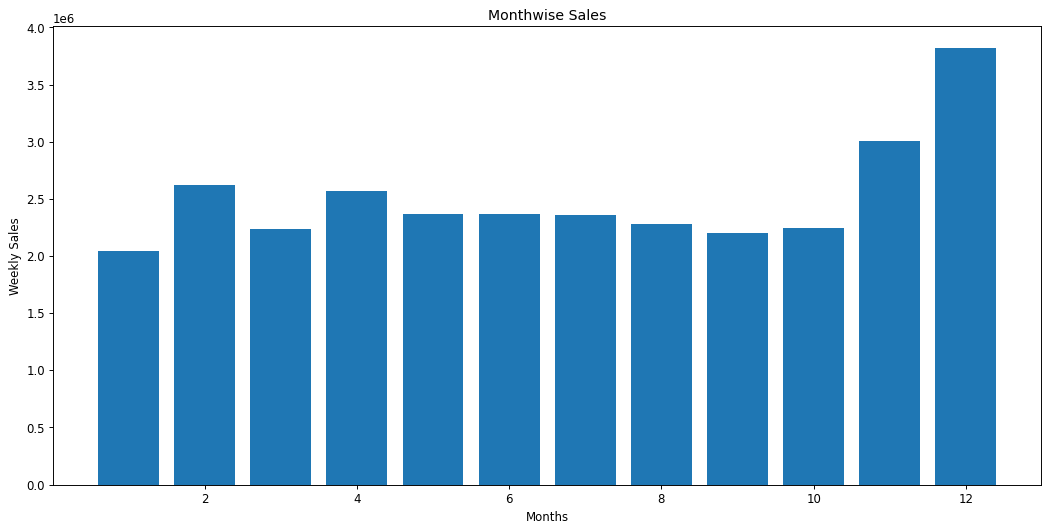

In [ ]:
plt.figure(figsize=(15,7), dpi=85)
plt.bar(df['month'],df['Weekly_Sales'])
plt.xlabel('Months')
plt.ylabel('Weekly Sales')
plt.title('Monthwise Sales')

In [ ]:
#Semesterwise Sales
df['semester']=np.where(df['month']<7,1,2)

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,day,semester
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5,1


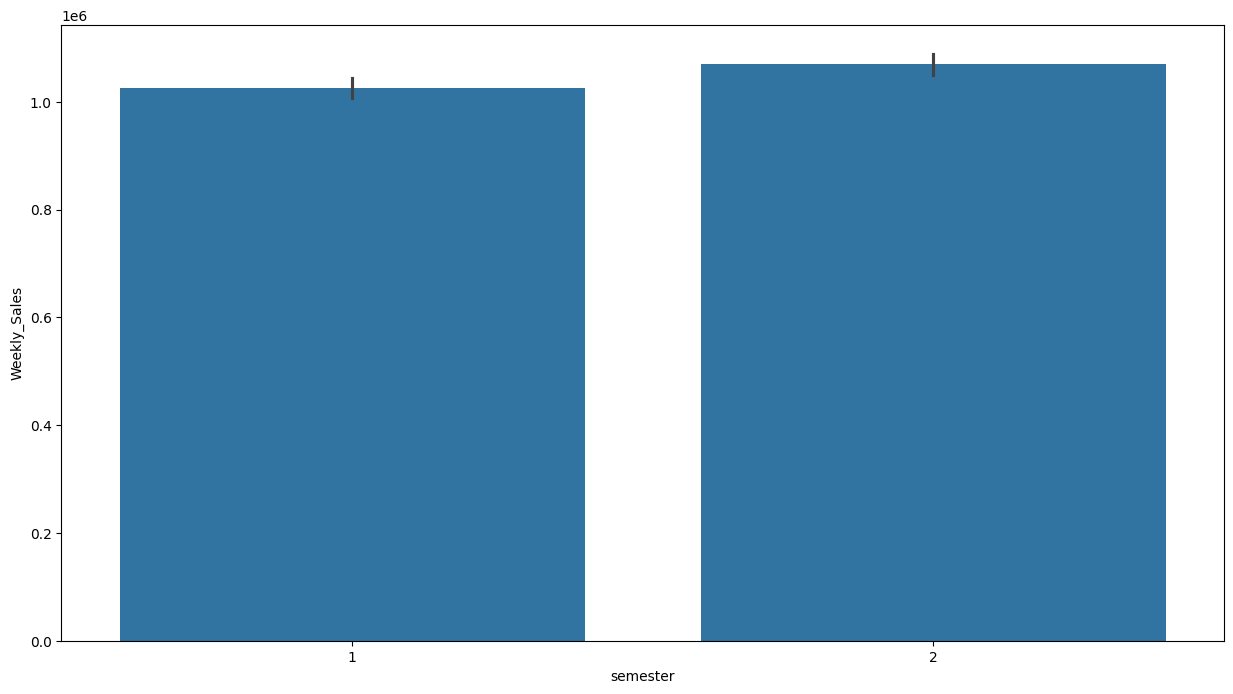

In [ ]:
plt.figure(figsize=(15,8))
semester=sns.barplot(x='semester',y='Weekly_Sales',data=df)

Insights drawn-(1)December month has the highest weekly sales. (2) Semester 2 has the highest weekly sales.

Model Building- First, define dependent and independent variables. Here, store, fuel price, CPI, unemployment, day, month, and year are the independent variables and weekly sales is the dependent variable. Now, it’s time to train the model. Import train_test_spit from sklearn.model_selection and train 80% of the data and test on the rest 20% of the data.

In [ ]:
#Define independent and dependent variable
#select features and target
x=df[['Store','Fuel_Price','CPI','Unemployment','day','month','year']]
y=df['Weekly_Sales']

In [ ]:
from sklearn.model_selection import train_test_split
# Split data to train and test (0.80:0.20)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

Linear Regression:

Accuracy: 14.513472093229062
Mean Absolute Error: 427697.8580235199
Mean Squared Error: 272270184589.69702
Root Mean Squared Error: 521795.1557744639


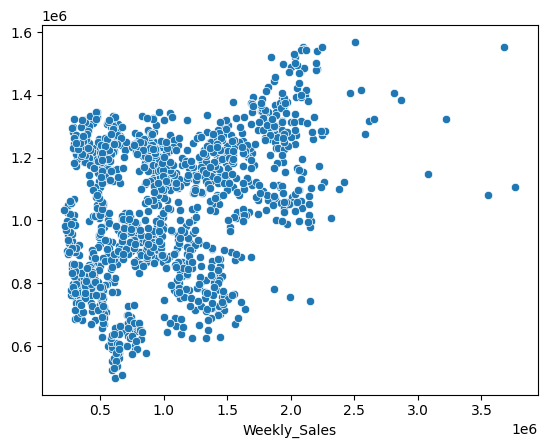

In [ ]:
#Liner Regression Model
print('Linear Regression:')
print()
reg=LinearRegression()
reg.fit(x_train,y_train)
y_pred=reg.predict(x_test)
print('Accuracy:',reg.score(x_train,y_train)*100)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))



sns.scatterplot(x=y_test, y=y_pred);

Random Forest Regressor:

Accuracy: 95.19016151891438
Mean Absolute Error: 65602.17837191475
Mean Squared Error: 15381740007.843925
Root Mean Squared Error: 124023.14303324168


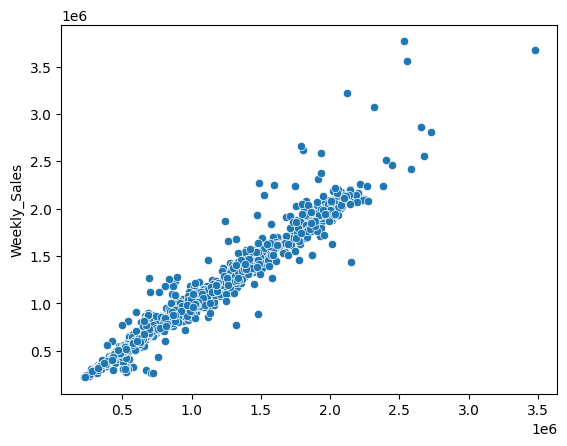

In [ ]:
#Random Forest Regressor
print('Random Forest Regressor:')
print()
rfr = RandomForestRegressor(n_estimators = 400,max_depth=15,n_jobs=5)
rfr.fit(x_train,y_train)
y_pred=rfr.predict(x_test)
print('Accuracy:',rfr.score(x_test, y_test)*100)

print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


sns.scatterplot(x=y_pred, y=y_test);

Here, we have used 2 different algorithms to know which model to use to predict the weekly sales. Linear Regression is not an appropriate model to use as accuracy is very low. However, Random Forest Regression gives an accuracy of almost 92%. so, it is the best model to forecast weekly sales.

In [ ]:
# Change dates into days by creating new variable.

df['day']=pd.to_datetime(df['Date']).dt.day_name()
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,day,semester
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,Friday,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,Friday,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,Friday,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,Friday,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,Friday,1


In [ ]:
experiment_day_start=5
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['exp_day'] = (df['Date']-df['Date'].min()).dt.days + experiment_day_start

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,day,semester,exp_day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,Friday,1,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,Friday,1,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,Friday,1,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,Friday,1,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,Friday,1,33


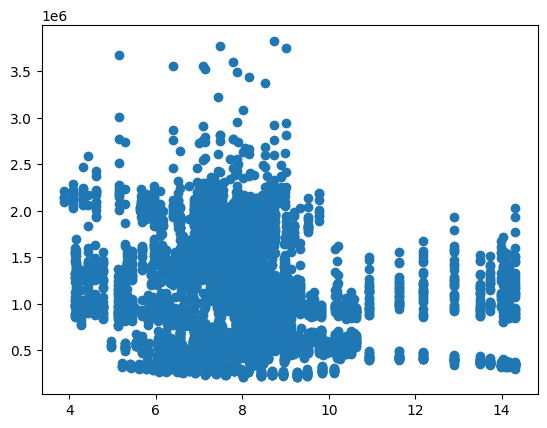

-0.10617608965795429


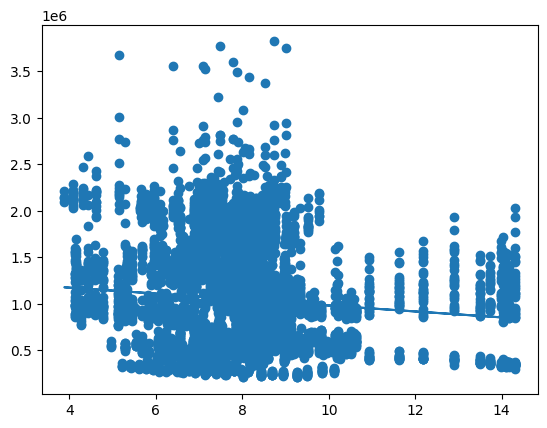

In [ ]:
from sklearn.linear_model import LinearRegression
from scipy import stats
#Weekly sales vs Unemployment
x = df['Unemployment']
y = df['Weekly_Sales']
plt.scatter(x, y)
plt.show()
slope, intercept, r, p, std_err = stats.linregress(x, y)
print(r)# r should be between -1 to 1
def myfunc(x):
  return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

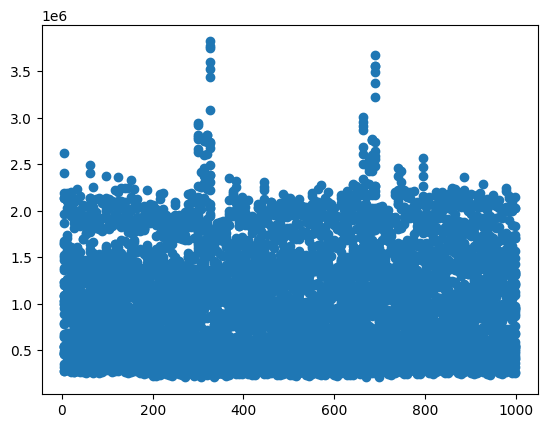

0.006949359783489027


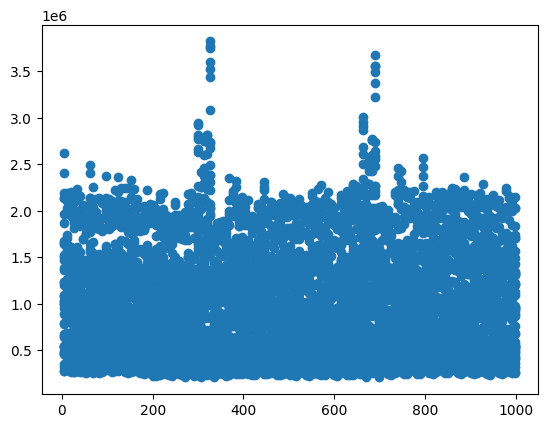

In [ ]:
# Weekly_Sales vs exp_day
x = df['exp_day']
y = df['Weekly_Sales']
plt.scatter(x, y)
plt.show()
slope, intercept, r, p, std_err = stats.linregress(x, y)
print(r)# r should be between -1 to 1
def myfunc(x):
  return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

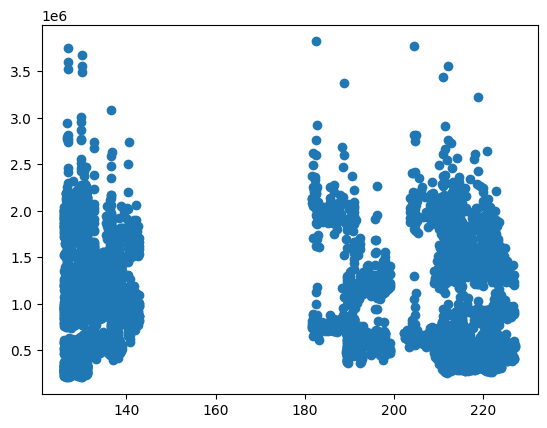

-0.07263416204017632


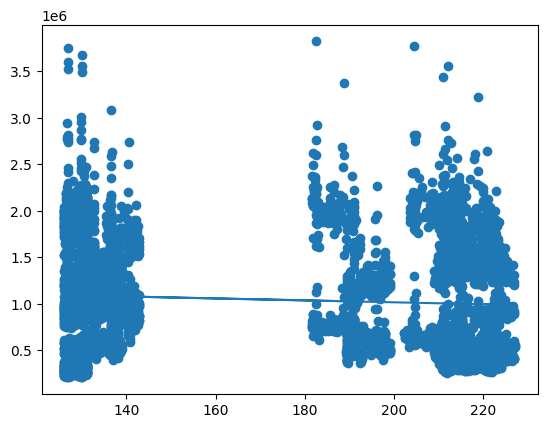

In [ ]:
#Weekly sales vs CPI
x = df['CPI']
y = df['Weekly_Sales']
plt.scatter(x, y)
plt.show()
slope, intercept, r, p, std_err = stats.linregress(x, y)
print(r)# r should be between -1 to 1
def myfunc(x):
  return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

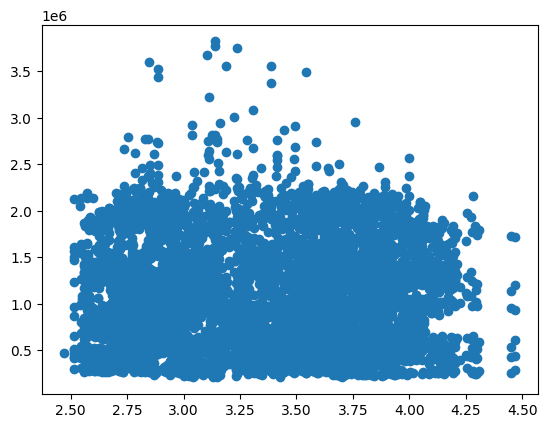

0.009463786314475114


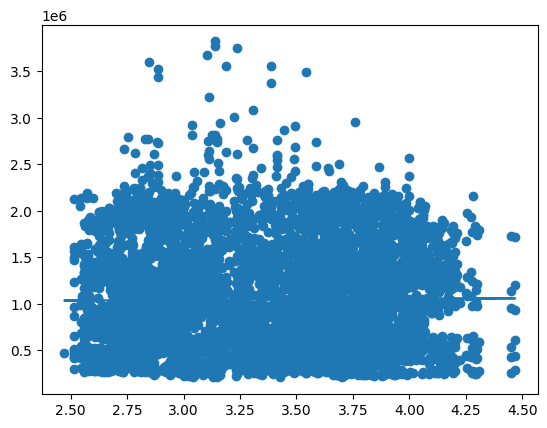

In [ ]:
#Weekly sales vs Fuel price
x = df['Fuel_Price']
y = df['Weekly_Sales']
plt.scatter(x, y)
plt.show()
slope, intercept, r, p, std_err = stats.linregress(x, y)
print(r)# r should be between -1 to 1
def myfunc(x):
 return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

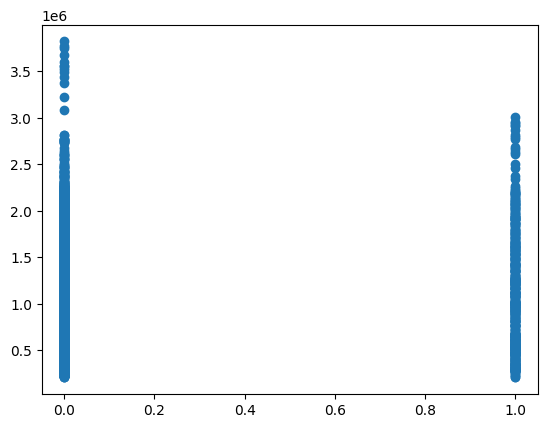

0.03689096801041456


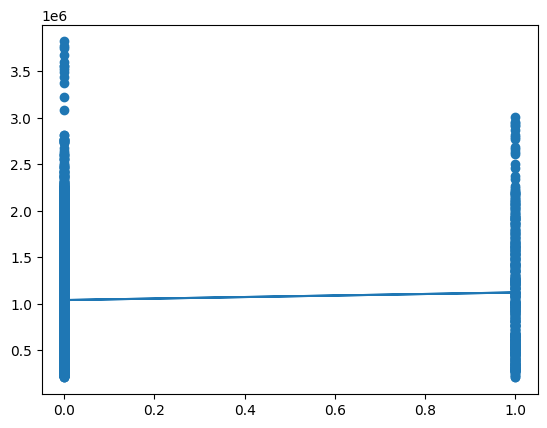

In [ ]:
#Weekly sales vs Holidays
x = df['Holiday_Flag']
y = df['Weekly_Sales']
plt.scatter(x, y)
plt.show()
slope, intercept, r, p, std_err = stats.linregress(x, y)
print(r)# r should be between -1 to 1
def myfunc(x):
  return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

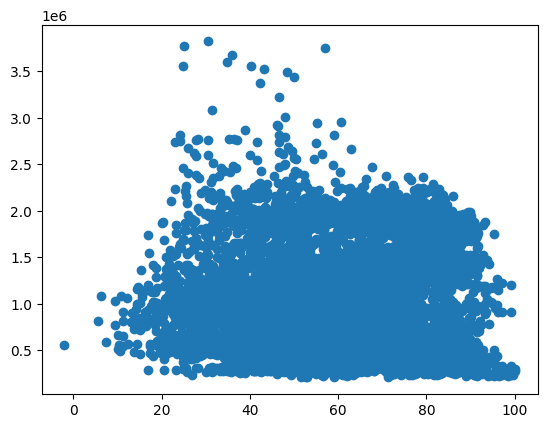

-0.06381001317946956


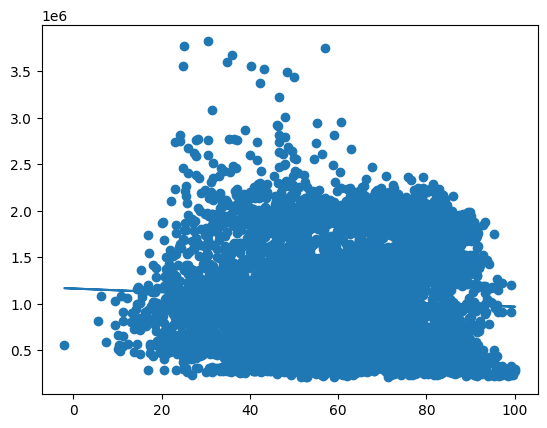

In [ ]:
#Weekly sales vs Temperature
x = df['Temperature']
y = df['Weekly_Sales']
plt.scatter(x, y)
plt.show()
slope, intercept, r, p, std_err = stats.linregress(x, y)
print(r)# r should be between -1 to 1
def myfunc(x):
  return slope * x + intercept
mymodel = list(map(myfunc, x))
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

In [ ]:
#Sorted the dataset for time series analysis.
df=df.sort_values('Date')

In [ ]:
#Selected 5 stores for performing store-wise analysis and forecasting.
stores = [1, 2, 3, 4, 5]

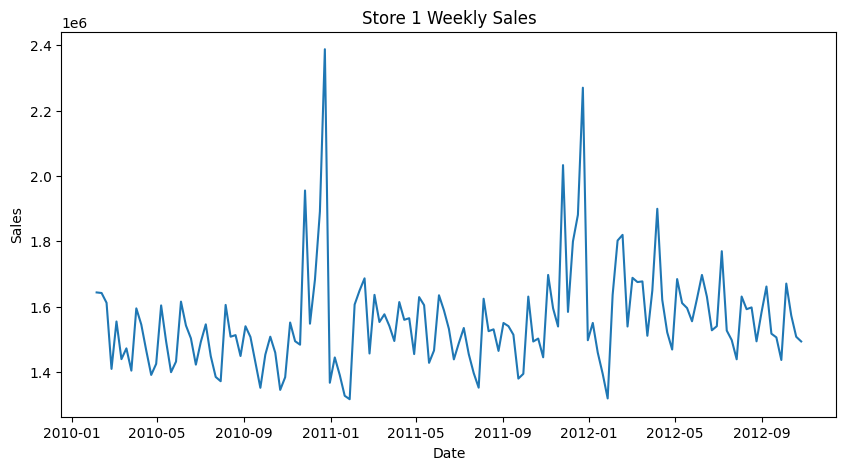

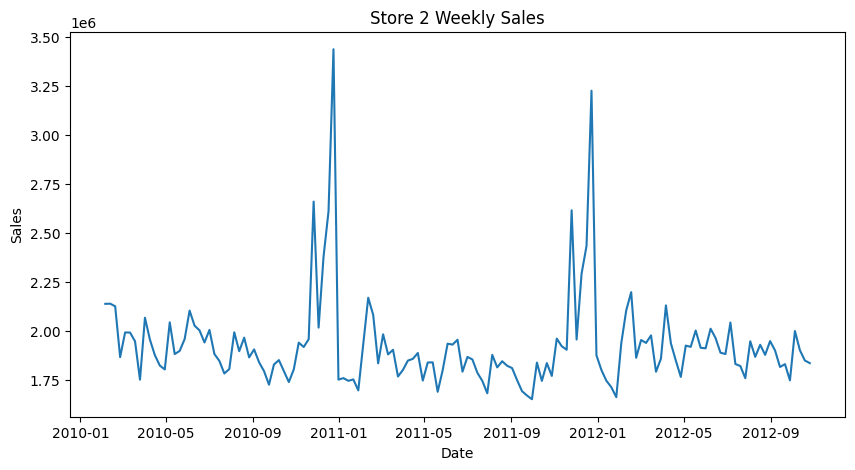

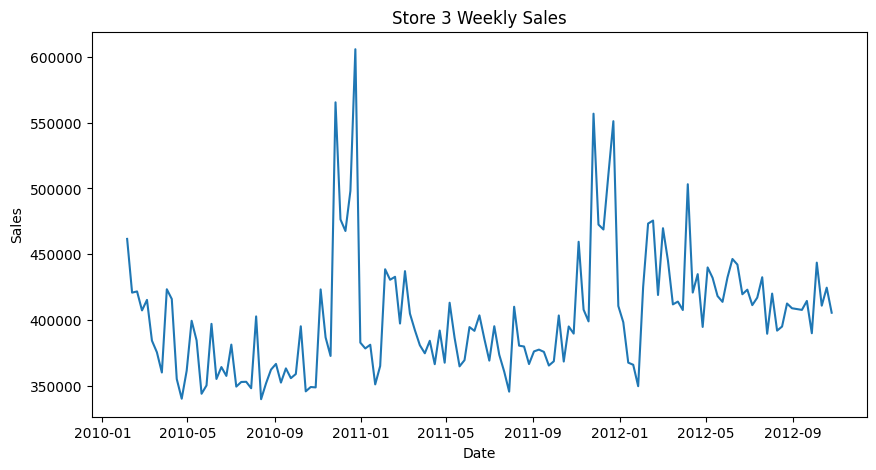

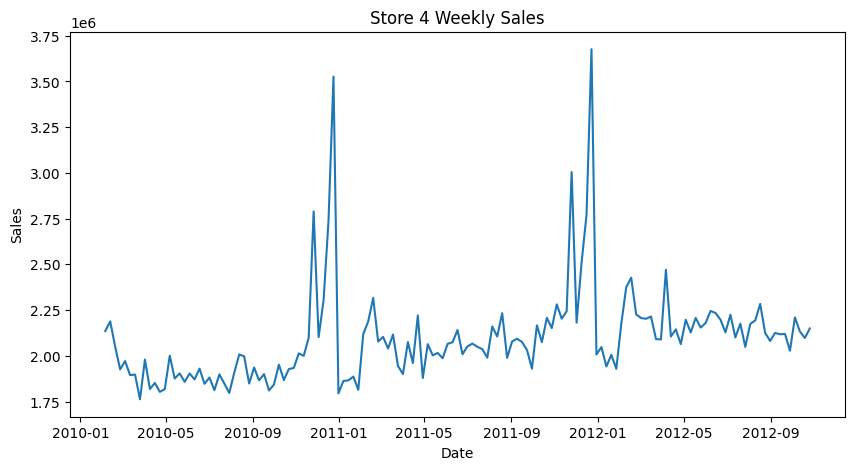

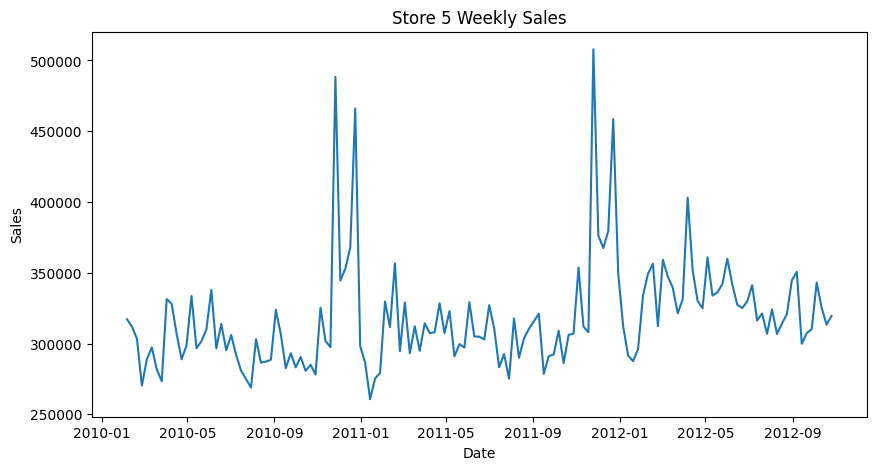

In [ ]:
#Visualized weekly sales trends for each store to understand patterns and variations over time.
for store in stores:
    store_data = df[df['Store'] == store]

    plt.figure(figsize=(10,5))
    plt.plot(store_data['Date'], store_data['Weekly_Sales'])
    plt.title(f"Store {store} Weekly Sales")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


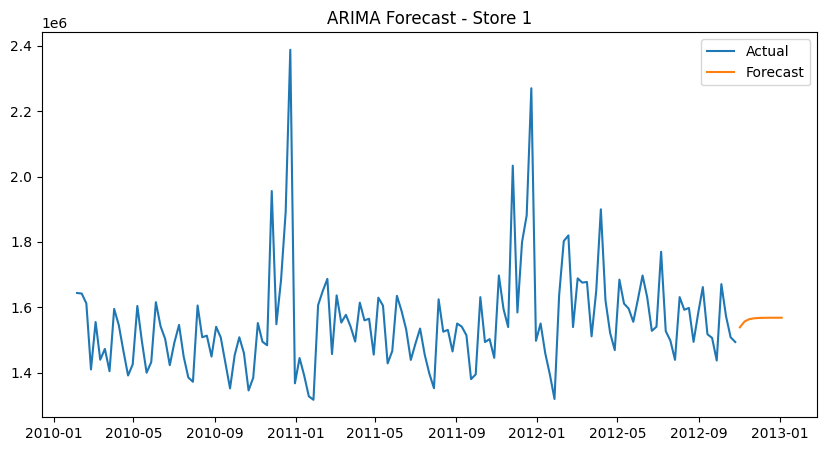

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


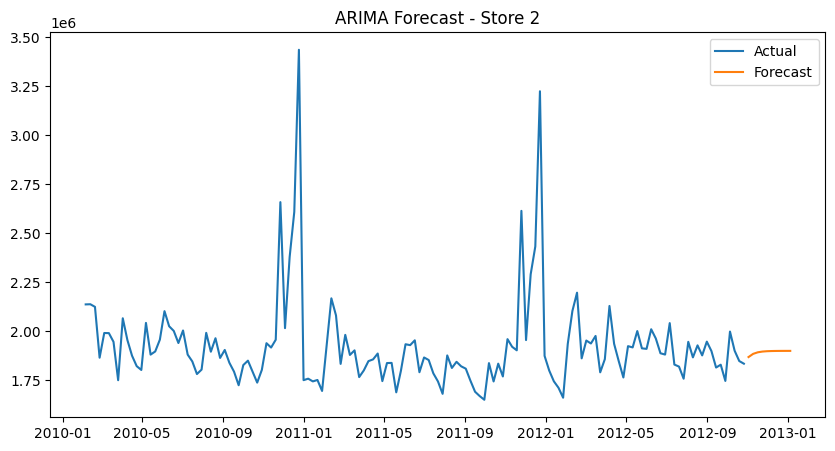

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


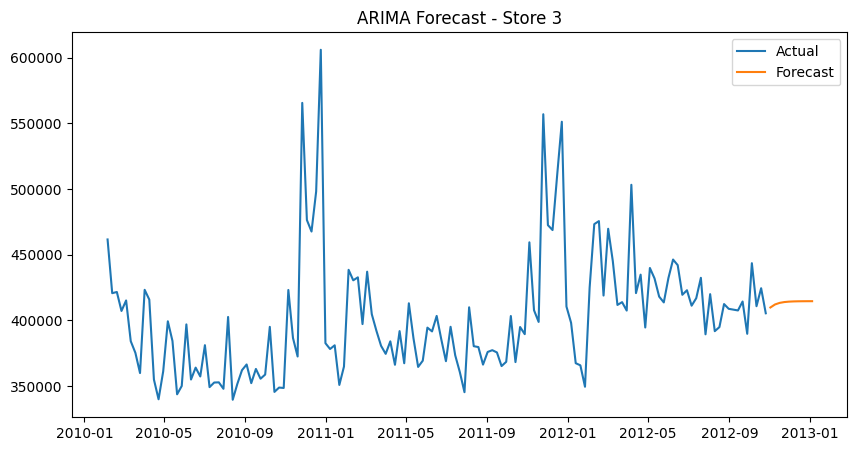

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


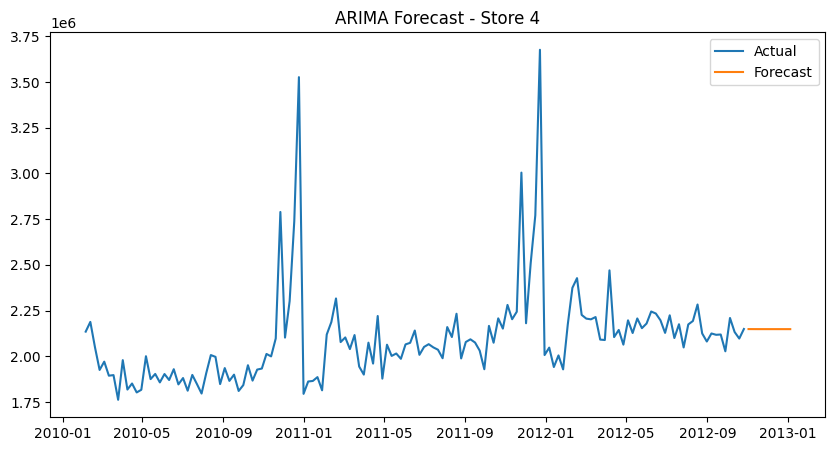

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


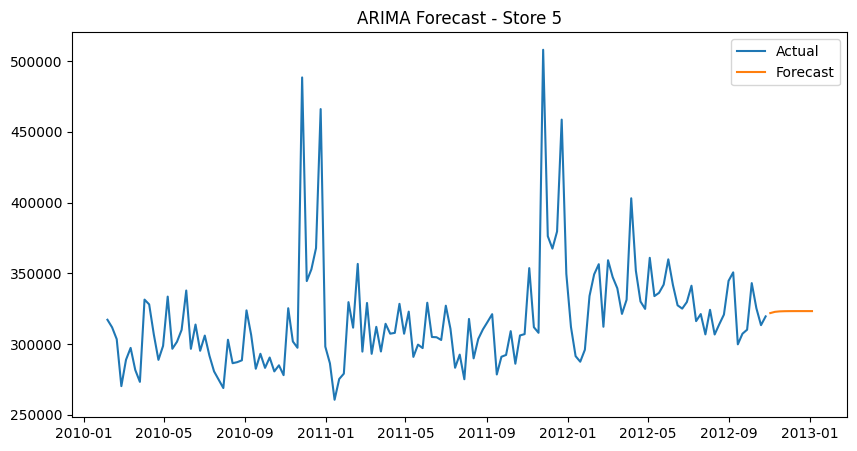

In [ ]:
#Time series Model building:
#Applied ARIMA model to forecast future weekly sales for each store based on historical data
for store in stores:
    store_data = df[df['Store'] == store]
    store_data = store_data.set_index('Date')

    model = ARIMA(store_data['Weekly_Sales'], order=(1,1,1))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=10)

    plt.figure(figsize=(10,5))
    plt.plot(store_data['Weekly_Sales'], label='Actual')
    plt.plot(forecast, label='Forecast')

    plt.title(f"ARIMA Forecast - Store {store}")
    plt.legend()
    plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


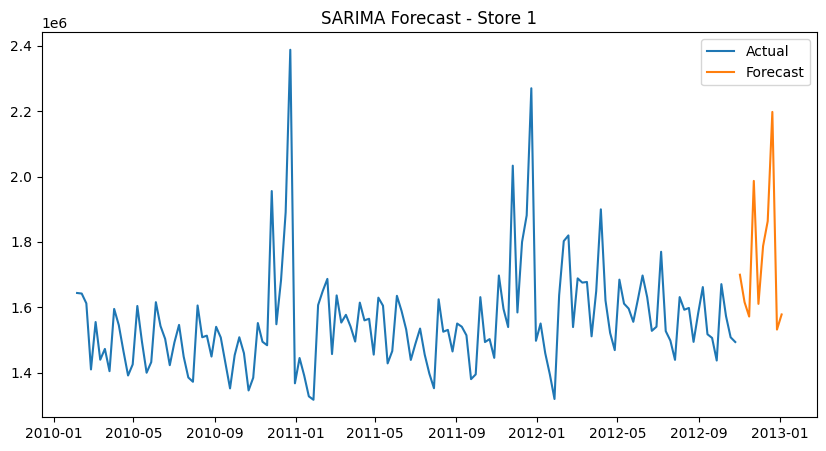

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


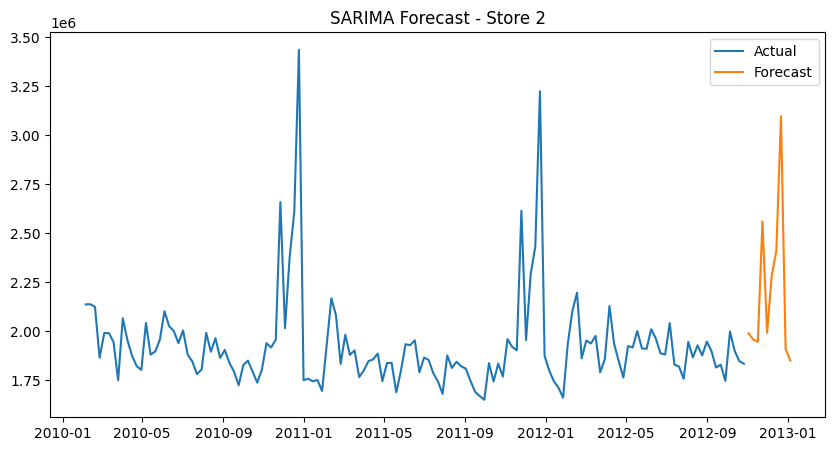

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


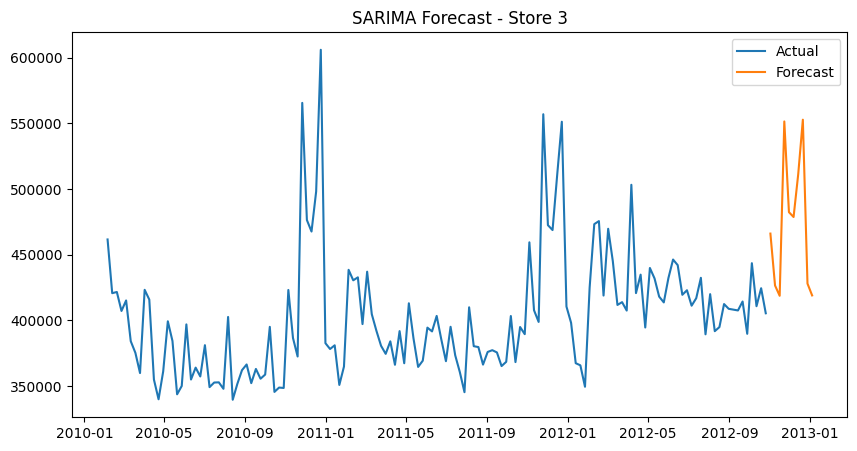

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


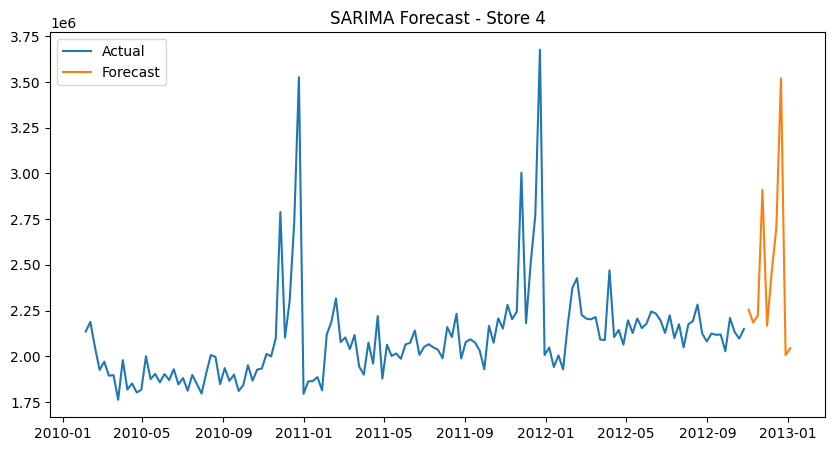

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


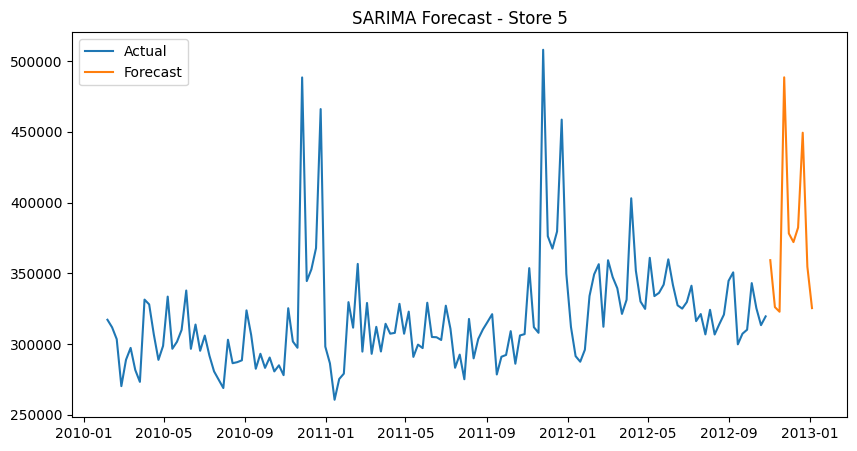

In [ ]:
#Used SARIMA model to capture seasonal patterns in weekly sales data and improve forecasting accuracy
for store in stores:
    store_data = df[df['Store'] == store]
    store_data = store_data.set_index('Date')

    model = SARIMAX(store_data['Weekly_Sales'],
                    order=(1,1,1),
                    seasonal_order=(1,1,1,52))

    model_fit = model.fit()
    forecast = model_fit.forecast(steps=10)

    plt.figure(figsize=(10,5))
    plt.plot(store_data['Weekly_Sales'], label='Actual')
    plt.plot(forecast, label='Forecast')

    plt.title(f"SARIMA Forecast - Store {store}")
    plt.legend()
    plt.show()



*   Time series forecasting was performed using ARIMA and SARIMA models for selected stores.
*   The models successfully captured trends and seasonal patterns in sales data.

*  Forecast plots show predicted future sales, which can help in demand planning and decision-making.



